<a href="https://colab.research.google.com/github/ASHIKAJAN/ABC-staff-company/blob/main/Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Employee.csv to Employee.csv


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Employee.csv')
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nShape of dataset:", df.shape)

First 5 rows:
   Company   Age  Salary     Place Country  Gender
0      TCS  20.0     NaN   Chennai   India       0
1  Infosys  30.0     NaN    Mumbai   India       0
2      TCS  35.0  2300.0  Calcutta   India       0
3  Infosys  40.0  3000.0     Delhi   India       0
4      TCS  23.0  4000.0    Mumbai   India       0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB
None

Shape of dataset: (148, 6)


In [3]:

for col in df.columns:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].unique())
    print("Length:", df[col].nunique())

print("\nStatistical Summary:")
print(df.describe())


df.rename(columns={
    'Place': 'Location',
    'Salary': 'Income'
}, inplace=True)

print("\nRenamed Columns:")
print(df.columns)


Column: Company
Unique values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Length: 6

Column: Age
Unique values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Length: 29

Column: Salary
Unique values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Length: 40

Column: Place
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Length: 11

Column: Country
Unique values: ['India']
Length: 1

Column: Gender
Unique values: [0 1]
Length: 2

Statistical Summary:
              Age       Salary      Gender
count  130.000000   124.000000  148.000000
mean    30.484615  5312.467742    0.222973
std     11.0


Missing Values:
Company      8
Age         24
Income      24
Location    14
Country      0
Gender       0
dtype: int64

Shape after removing duplicates: (144, 6)


/tmp/ipykernel_8460/736748683.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_8460/736748683.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

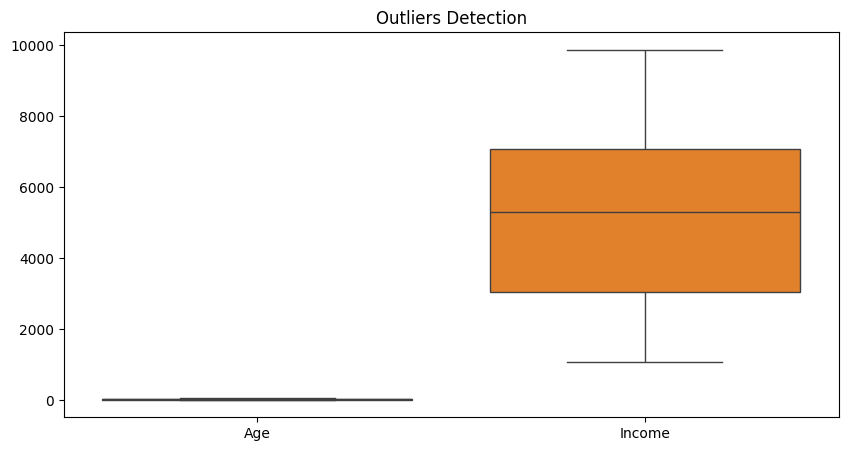


Shape after removing outliers: (144, 6)


In [4]:

df['Age'] = df['Age'].replace(0, np.nan)


print("\nMissing Values:")
print(df.isnull().sum())


df['Age'].fillna(df['Age'].median(), inplace=True)
df['Income'].fillna(df['Income'].mean(), inplace=True)
df['Location'].fillna(df['Location'].mode()[0], inplace=True)

df.drop_duplicates(inplace=True)

print("\nShape after removing duplicates:", df.shape)


plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Age','Income']])
plt.title("Outliers Detection")
plt.show()


Q1 = df[['Age','Income']].quantile(0.25)
Q3 = df[['Age','Income']].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[['Age','Income']] < (Q1 - 1.5 * IQR)) |
          (df[['Age','Income']] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("\nShape after removing outliers:", df.shape)

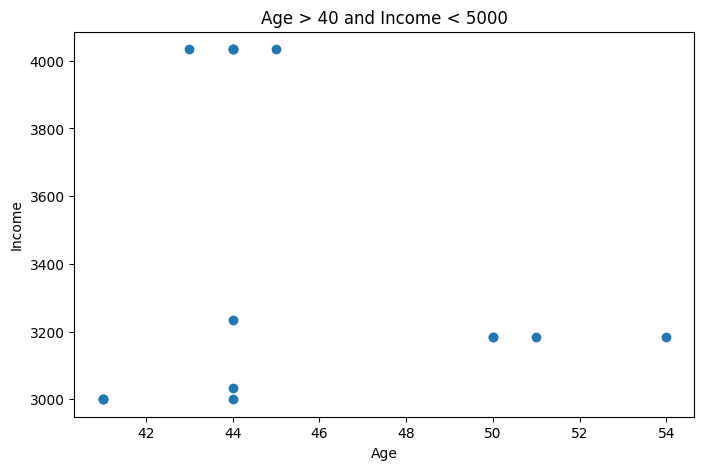

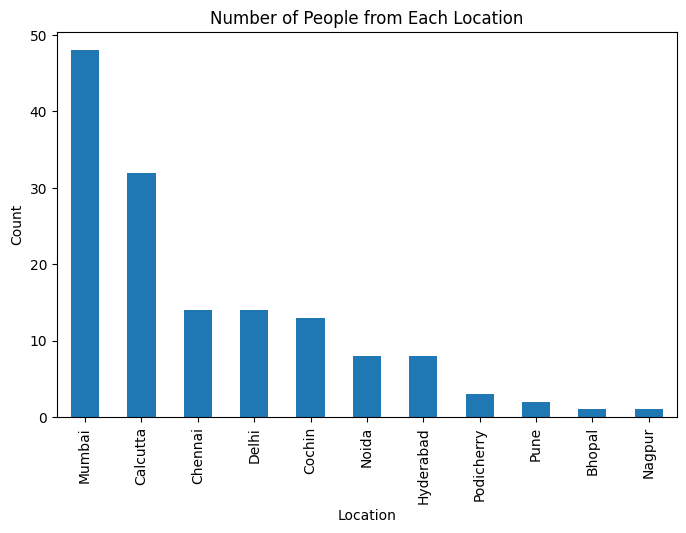

In [5]:

filtered_df = df[(df['Age'] > 40) & (df['Income'] < 5000)]


plt.figure(figsize=(8,5))
plt.scatter(filtered_df['Age'], filtered_df['Income'])
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Age > 40 and Income < 5000")
plt.show()


location_counts = df['Location'].value_counts()


plt.figure(figsize=(8,5))
location_counts.plot(kind='bar')
plt.title("Number of People from Each Location")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

In [6]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])


df = pd.get_dummies(df, columns=['Location'], drop_first=True)

print("\nEncoded Data:")
print(df.head())


Encoded Data:
   Company   Age       Income Country  Gender  Location_Calcutta  \
0      TCS  20.0  5312.467742   India       0              False   
1  Infosys  30.0  5312.467742   India       0              False   
2      TCS  35.0  2300.000000   India       0               True   
3  Infosys  40.0  3000.000000   India       0              False   
4      TCS  23.0  4000.000000   India       0              False   

   Location_Chennai  Location_Cochin  Location_Delhi  Location_Hyderabad  \
0              True            False           False               False   
1             False            False           False               False   
2             False            False           False               False   
3             False            False            True               False   
4             False            False           False               False   

   Location_Mumbai  Location_Nagpur  Location_Noida  Location_Podicherry  \
0            False            False        

In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


num_cols = ['Age', 'Income']

scaler_std = StandardScaler()
df_std = df.copy()
df_std[num_cols] = scaler_std.fit_transform(df[num_cols])

print("\nStandard Scaled Data:")
print(df_std.head())


scaler_mm = MinMaxScaler()
df_mm = df.copy()
df_mm[num_cols] = scaler_mm.fit_transform(df[num_cols])

print("\nMinMax Scaled Data:")
print(df_mm.head())


Standard Scaled Data:
   Company       Age    Income Country  Gender  Location_Calcutta  \
0      TCS -1.484676  0.010324   India       0              False   
1  Infosys -0.267174  0.010324   India       0              False   
2      TCS  0.341577 -1.266072   India       0               True   
3  Infosys  0.950328 -0.969479   India       0              False   
4      TCS -1.119426 -0.545775   India       0              False   

   Location_Chennai  Location_Cochin  Location_Delhi  Location_Hyderabad  \
0              True            False           False               False   
1             False            False           False               False   
2             False            False           False               False   
3             False            False            True               False   
4             False            False           False               False   

   Location_Mumbai  Location_Nagpur  Location_Noida  Location_Podicherry  \
0            False           